Shapes:
  true_norm: (200000,)
  pred_norm: (200000,)
  true_denorm: (200000,)
  pred_denorm: (200000,)
✔ Arrays align perfectly.

==== METRICS (normalized) ====
MSE (norm): 0.034416
MAE (norm): 0.052631
R²  (norm): 0.971018

==== METRICS (denormalized) ====
MSE: 102040.750000
MAE: 90.625153
R² : 0.971018


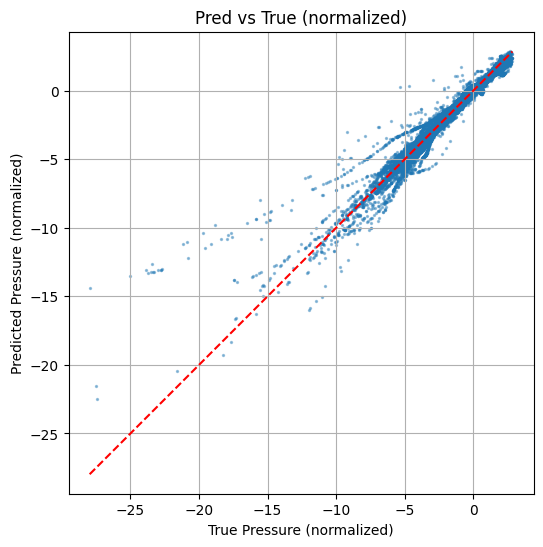

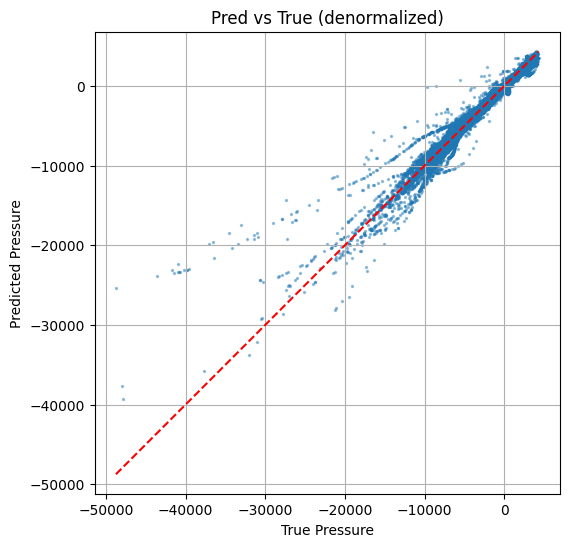

In [1]:
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------
# SET YOUR FOLDER HERE
# -----------------------
folder = "all_score_baseline4/scarce/GraphSAGE"

# Load files
true_norm = np.load(os.path.join(folder, "true_norm.npy"))
pred_norm = np.load(os.path.join(folder, "pred_norm.npy"))
true_denorm = np.load(os.path.join(folder, "true_denorm.npy"))
pred_denorm = np.load(os.path.join(folder, "pred_denorm.npy"))

# Flatten
true_norm = true_norm.reshape(-1)
pred_norm = pred_norm.reshape(-1)
true_denorm = true_denorm.reshape(-1)
pred_denorm = pred_denorm.reshape(-1)

# -----------------------
# Alignment check
# -----------------------
print("Shapes:")
print("  true_norm:", true_norm.shape)
print("  pred_norm:", pred_norm.shape)
print("  true_denorm:", true_denorm.shape)
print("  pred_denorm:", pred_denorm.shape)

if not (len(true_norm) == len(pred_norm) == len(true_denorm) == len(pred_denorm)):
    raise RuntimeError("❌ Arrays DO NOT ALIGN — check preprocessing!")

print("✔ Arrays align perfectly.")


# -----------------------
# Metrics (normalized)
# -----------------------
mse_norm = mean_squared_error(true_norm, pred_norm)
mae_norm = mean_absolute_error(true_norm, pred_norm)
r2_norm = r2_score(true_norm, pred_norm)

print("\n==== METRICS (normalized) ====")
print(f"MSE (norm): {mse_norm:.6f}")
print(f"MAE (norm): {mae_norm:.6f}")
print(f"R²  (norm): {r2_norm:.6f}")


# -----------------------
# Metrics (denormalized)
# -----------------------
mse_den = mean_squared_error(true_denorm, pred_denorm)
mae_den = mean_absolute_error(true_denorm, pred_denorm)
r2_den = r2_score(true_denorm, pred_denorm)

print("\n==== METRICS (denormalized) ====")
print(f"MSE: {mse_den:.6f}")
print(f"MAE: {mae_den:.6f}")
print(f"R² : {r2_den:.6f}")


# -----------------------
# Plot: normalized
# -----------------------
plt.figure(figsize=(6,6))
plt.scatter(true_norm, pred_norm, s=2, alpha=0.4)
plt.plot([true_norm.min(), true_norm.max()],
         [true_norm.min(), true_norm.max()],
         'r--')
plt.xlabel("True Pressure (normalized)")
plt.ylabel("Predicted Pressure (normalized)")
plt.title("Pred vs True (normalized)")
plt.axis("equal")
plt.grid(True)
plt.show()


# -----------------------
# Plot: denormalized
# -----------------------
plt.figure(figsize=(6,6))
plt.scatter(true_denorm, pred_denorm, s=2, alpha=0.4)
plt.plot([true_denorm.min(), true_denorm.max()],
         [true_denorm.min(), true_denorm.max()],
         'r--')
plt.xlabel("True Pressure")
plt.ylabel("Predicted Pressure")
plt.title("Pred vs True (denormalized)")
plt.axis("equal")
plt.grid(True)
plt.show()


In [2]:
import numpy as np
import os
import torch

folder = "all_score_baseline4/scarce/GraphSAGE"

true = np.load(os.path.join(folder, "true_denorm.npy"))
pred = np.load(os.path.join(folder, "pred_denorm.npy"))

# Load positions to verify alignment
# Only works if you saved test_dataset or positions separately
test_dataset = torch.load("save_dataset/baseline3/test_dataset", map_location="cpu",weights_only=False)

# Reconstruct concatenated pos
pos_list = []
for data in test_dataset:
    pos_list.append(data.pos[data.surf].numpy())

pos = np.concatenate(pos_list)

# Now verify alignment:
for i in [0, 100, 200, 500, 1000]:
    print(f"Point {i}: pos = {pos[i]}, true = {true[i]}, pred = {pred[i]}")


Point 0: pos = [ 0.97052836 -0.00671202], true = [99.88019], pred = [111.30524]
Point 100: pos = [ 0.57574534 -0.07538356], true = [-128.0524], pred = [-135.55573]
Point 200: pos = [ 0.62131673 -0.06942347], true = [-108.95828], pred = [-130.52652]
Point 500: pos = [ 0.7874562  -0.04322645], true = [-34.44397], pred = [-55.65222]
Point 1000: pos = [ 0.10333493 -0.01388815], true = [702.0337], pred = [707.4315]
